[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kavit\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[[4359  602]
 [ 473 4566]]


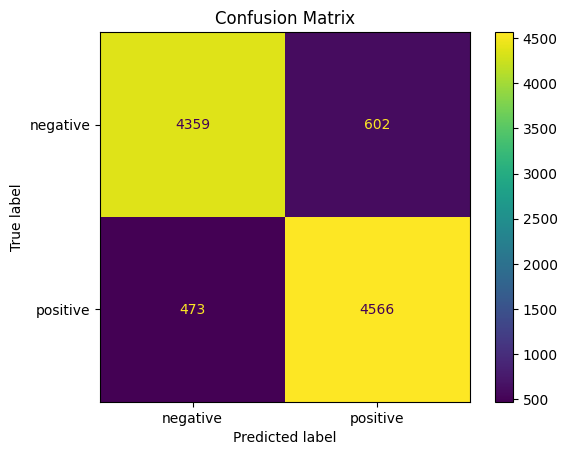

Accuracy: 0.8925


Enter a movie review:  worst movie ever


Sentiment: negative
Confidence: 99.28 %
              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4961
    positive       0.88      0.91      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [86]:
import pandas as pd
import re
import nltk
import pickle

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Download stopwords
nltk.download('stopwords')

# Load dataset
df = pd.read_csv("IMDB Dataset.csv")

# Stopwords
stop_words = set(stopwords.words('english'))

# Cleaning function
def clean_text(text):

    text = text.lower()

    text = re.sub(r'<.*?>', '', text)

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

# Apply cleaning
df['review'] = df['review'].apply(clean_text)

# Features and target
X = df['review']
Y = df['sentiment']

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X = tfidf.fit_transform(X)

# Train Test Split
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

# Model
model = LogisticRegression(max_iter=1000)

# Training
model.fit(X_train, Y_train)

# Prediction
Y_pred = model.predict(X_test)

cm = confusion_matrix(Y_test, Y_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

# Accuracy
accuracy = accuracy_score(Y_test, Y_pred)

print("Accuracy:", accuracy)

# User Input
review = input("Enter a movie review: ")

review = clean_text(review)

review_vector = tfidf.transform([review])

prediction = model.predict(review_vector)

probabilities = model.predict_proba(review_vector)

confidence = max(probabilities[0]) * 100

print("Sentiment:", prediction[0])
print("Confidence:", round(confidence, 2), "%")

print(classification_report(Y_test, Y_pred))

# Save model
pickle.dump(model, open("sentiment_model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf_vectorizer.pkl", "wb"))